In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime


API_KEY = "d44b3733f567d0285092174cc14f276b"


cities = ["Ahmedabad","Mumbai","Delhi","Bangalore","Chennai"]

# -------------------------------------------

weather_data = []

# -------------------------------------------

for city in cities:
    url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"

    response = requests.get(url)

    data = response.json()

    if response.status_code == 200:

        city_weather = {
            "City": city,
            "Temperature": data["main"]["temp"],
            "Humidity": data["main"]["humidity"],
            "Weather": data["weather"][0]["main"],
            "Wind Speed": data["wind"]["speed"],
            "Date": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        }

        weather_data.append(city_weather)

    else:
        print(f"Error fetching data for {city}")

# -------------------------------------------

df = pd.DataFrame(weather_data)

# -------------------------------------------

print("\nWeather Data:\n")
print(df)



Weather Data:

        City  Temperature  Humidity Weather  Wind Speed                 Date
0  Ahmedabad        33.57        49  Clouds        4.78  2026-07-20 11:58:40
1     Mumbai        28.20        79  Clouds        7.86  2026-07-20 11:58:41
2      Delhi        34.00        51  Clouds        3.48  2026-07-20 11:58:42
3  Bangalore        27.60        62  Clouds        7.55  2026-07-20 11:58:43
4    Chennai        33.40        58  Clouds        1.34  2026-07-20 11:58:44


In [4]:

# -------------------------------------------

print("\nAverage Temperature:")
print(df["Temperature"].mean())

print("\nMaximum Temperature:")
print(df["Temperature"].max())

print("\nMinimum Temperature:")
print(df["Temperature"].min())



Average Temperature:
31.354000000000003

Maximum Temperature:
34.0

Minimum Temperature:
27.6


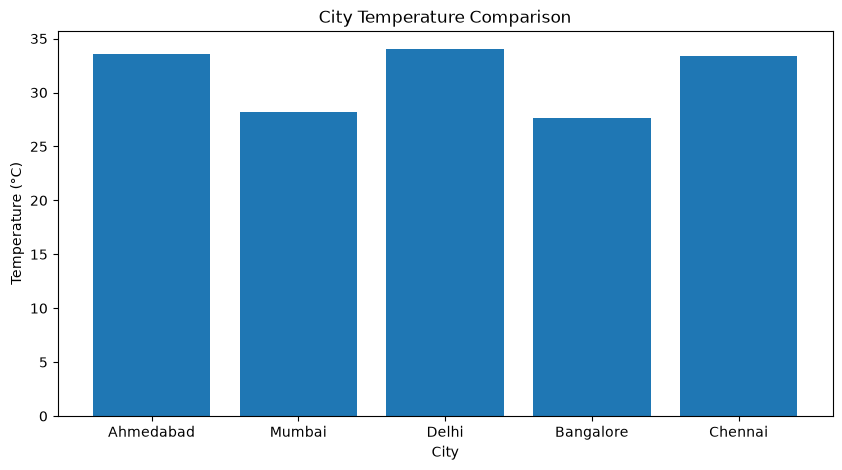

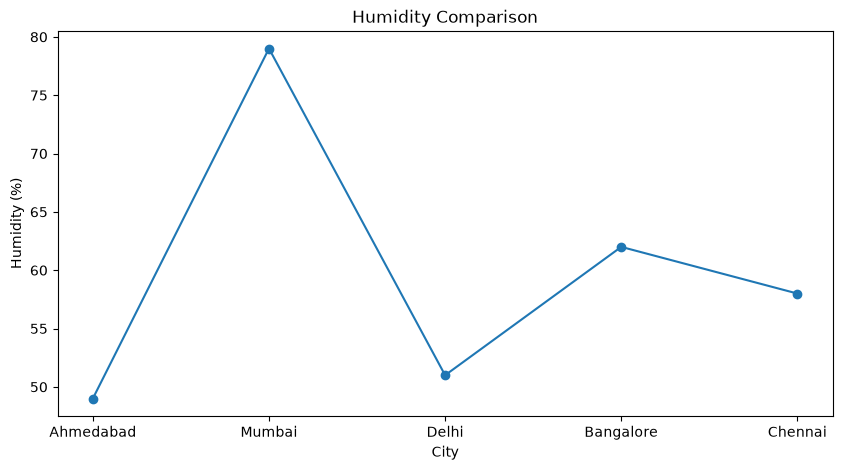


Weather report exported successfully!


In [5]:

# -------------------------------------------

plt.figure(figsize=(10, 5))

plt.bar(df["City"], df["Temperature"])

plt.title("City Temperature Comparison")
plt.xlabel("City")
plt.ylabel("Temperature (°C)")

plt.show()

# -------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(df["City"], df["Humidity"], marker='o')

plt.title("Humidity Comparison")
plt.xlabel("City")
plt.ylabel("Humidity (%)")

plt.show()

# -------------------------------------------

df.to_csv("weather_report.csv", index=False)

print("\nWeather report exported successfully!")